# DESCRIPTORES FORMA Y TEXTURA
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 02/06/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **







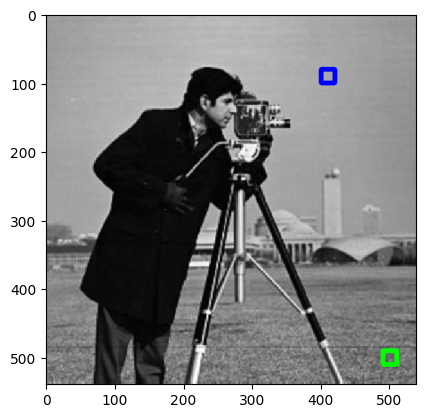

In [3]:
# En primer lugar, obtenemos la máscara de la imagen original mediante laumbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/images/photographer.png')
window = cv2.rectangle(img.copy(), (400,80), (420,100), (0, 0, 255), 5)
window = cv2.rectangle(window, (490,490), (510,510), (0, 255, 0), 5)
plt.imshow(window, cmap='gray')
plt.show()


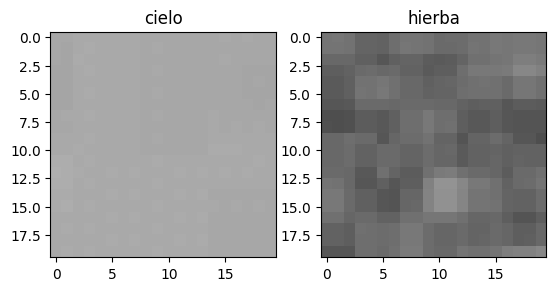

In [4]:
# Seleccionamos una región del cielo y una de la hierba
cielo = img[80:100, 400:420]
hierba = img[490:510, 490:510]
fig, ax = plt.subplots(1,2)
ax[0].imshow(cielo, cmap='gray')
ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray')
ax[1].set_title('hierba')
plt.show()


# 0.0.1 MATRIZ DE COOCURRENCIA

In [5]:
# MATRIZ DE COOCURRENCIA (Gray-Level Co-occurrence Matrix - GLCM)
# La matriz de co-ocurrencia es una técnica estadística para análisis de textura en imágenes

# Importa la biblioteca 'tabulate' para mostrar tablas formateadas en consola
from tabulate import tabulate

# Importa las funciones para calcular la matriz de co-ocurrencia y sus propiedades
# graycomatrix: calcula la matriz GLCM
# graycoprops: extrae propiedades estadísticas de la matriz GLCM
from skimage.feature.texture import graycomatrix, graycoprops

# Importa OpenCV para procesamiento de imágenes (convertir a escala de grises)
import cv2

# Define los encabezados de la tabla: primera columna vacía, luego 'cielo' y 'hierba'
headers = ['', 'cielo', 'hierba']

# Inicializa listas para almacenar las 6 propiedades de textura que se calcularán
# Cada lista comienza con el nombre de la propiedad como primer elemento
CN = ['contraste']      # Contraste: mide variaciones locales de intensidad
DIS = ['disimilitud']   # Disimilitud: similar al contraste pero con ponderación lineal
H = ['homogeneidad']    # Homogeneidad: mide qué tan cerca están los valores entre sí
ASM = ['ASM']          # Segundo Momento Angular: mide uniformidad de la textura
E = ['Energía']        # Energía: raíz cuadrada del ASM, mide orden de la textura
COR = ['Correlación']  # Correlación: mide dependencia lineal entre píxeles

# Crea una lista vacía llamada 'patches' para almacenar las imágenes
patches = []

# Agrega las imágenes 'cielo' y 'hierba' a la lista 'patches'
# NOTA: Estas variables deben haber sido definidas previamente en el código
patches.append(cielo)
patches.append(hierba)

# Itera sobre cada imagen en la lista 'patches' (índice i = 0 para cielo, 1 para hierba)
for i in range(len(patches)):
    
    # Convierte la imagen de color BGR (formato de OpenCV) a escala de grises
    # Esto es necesario porque GLCM trabaja con imágenes de un solo canal
    image = cv2.cvtColor(patches[i], cv2.COLOR_BGR2GRAY)
    
    # Calcula la matriz GLCM con los siguientes parámetros:
    # distances=[5]: considera píxeles a 5 posiciones de distancia
    # angles=[0]: considera solo dirección horizontal (0 grados)
    # levels=256: usa 256 niveles de gris (0-255)
    # symmetric=True: hace la matriz simétrica (considera ambas direcciones)
    # normed=True: normaliza la matriz (valores entre 0 y 1)
    GLCM = graycomatrix(image, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
    
    # Extrae y almacena las 6 propiedades de textura para la imagen actual
    # [0,0] accede al primer valor de la matriz (distancia=5, ángulo=0)
    CN.append(graycoprops(GLCM, 'contrast')[0,0])        # Añade contraste
    DIS.append(graycoprops(GLCM, 'dissimilarity')[0,0])  # Añade disimilitud
    H.append(graycoprops(GLCM, 'homogeneity')[0,0])      # Añade homogeneidad
    ASM.append(graycoprops(GLCM, 'ASM')[0,0])           # Añade ASM
    E.append(graycoprops(GLCM, 'energy')[0,0])          # Añade energía
    COR.append(graycoprops(GLCM, 'correlation')[0,0])   # Añade correlación

# Crea una lista de tuplas para construir la tabla:
# Cada tupla contiene [nombre_propiedad, valor_cielo, valor_hierba]
my_data = [tuple(CN), tuple(DIS), tuple(H), tuple(ASM), tuple(E), tuple(COR)]

# Imprime la tabla formateada con los encabezados definidos
# Esto mostrará una tabla comparativa de las propiedades de textura
# entre las imágenes de cielo y hierba
print(tabulate(my_data, headers=headers))

                 cielo        hierba
------------  --------  ------------
contraste     3.68      333.393
disimilitud   1.4        13.8533
homogeneidad  0.512471    0.0921279
ASM           0.142717    0.00510556
Energía       0.377779    0.0714532
Correlación   0.190521   -0.0705127


# 0.0.2 Scale-Invariant Feature Transform

(1672, 128)


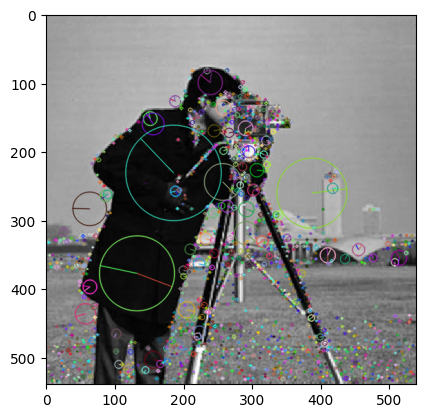

In [6]:
# SIFT algorithm (Scale-Invariant Feature Transform)
# SIFT es un algoritmo para detectar y describir características locales en imágenes
# Es invariante a escala, rotación y parcialmente a cambios de iluminación

# Importa OpenCV para procesamiento de imágenes
import cv2

# Importa NumPy para operaciones con arreglos (aunque no se usa directamente aquí)
import numpy as np

# Importa matplotlib para visualización de imágenes
import matplotlib.pyplot as plt

# Lee la imagen desde la ruta especificada
# La imagen 'photographer.png' debe existir en la carpeta 'images/photographer.png'
img = cv2.imread('images/images/photographer.png')

# NOTA: cv2.imread() carga la imagen en formato BGR (Blue, Green, Red)
# Si la imagen no se encuentra, img será None

# Definición del algoritmo SIFT
# SIFT_create() crea un objeto detector/descriptor SIFT
# Este objeto contiene todos los parámetros del algoritmo:
# - número de octavas
# - umbral de contraste
# - umbral de borde, etc.
sift = cv2.SIFT_create()

# Identificamos los puntos de interés (keypoints) en la imagen
# detect() encuentra ubicaciones clave en la imagen que son estables a cambios de escala
# Parámetros:
#   - img: imagen de entrada (debe estar en escala de grises normalmente)
#   - None: máscara (None = usar toda la imagen)
# Retorna: lista de objetos KeyPoint (cada uno con posición, tamaño, orientación, etc.)
kp = sift.detect(img, None)

# Extraemos el descriptor para obtener el "fingerprint" de cada punto clave
# compute() calcula un vector descriptor para cada keypoint
# Los descriptores SIFT son vectores de 128 dimensiones que describen el entorno del punto
# Parámetros:
#   - img: imagen de entrada
#   - kp: lista de keypoints detectados
# Retorna:
#   - kp: lista actualizada de keypoints (puede filtrar algunos)
#   - des: matriz de descriptores (N x 128, donde N = número de keypoints)
kp, des = sift.compute(img, kp)

# Imprime la dimensión de la matriz de descriptores
# Formato: (número_de_keypoints, 128)
# Cada fila representa un punto clave y sus 128 características numéricas
print(np.shape(des))

# Línea comentada: muestra la matriz completa de descriptores
# Útil para depuración pero muy grande para imprimir normalmente
# print(des) # Matriz donde las filas son los keypoints y las columnas las características de dichos puntos clave

# Visualizamos los puntos de interés superpuestos en la imagen original
# drawKeypoints() dibuja los keypoints en la imagen
# Parámetros:
#   - img: imagen original
#   - kp: keypoints a dibujar
#   - img: imagen de salida (sobreescribe la original)
#   - flags: estilo de dibujo
#     DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS: dibuja círculos con tamaño y orientación
#     Otras opciones: DEFAULT (solo puntos), DRAW_OVER_OUTIMG (sobre la imagen)
img = cv2.drawKeypoints(img, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Muestra la imagen con matplotlib
# IMPORTANTE: matplotlib espera RGB, pero OpenCV usa BGR
# Los colores pueden aparecer incorrectos (azul/rojo invertidos)
plt.imshow(img)

# Muestra la ventana con la imagen
plt.show()

# 0.0.3 Histogram of Oriented Gradients

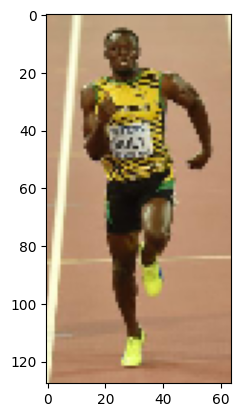

In [7]:
# HISTOGRAM OF ORIENTED GRADIENTS (HOG)
# HOG es un descriptor de características utilizado principalmente para detección de objetos
# Es especialmente efectivo para detectar peatones, vehículos y otros objetos con formas definidas

# Importa la biblioteca scikit-image para leer imágenes
from skimage import io

# Importa NumPy para operaciones numéricas con arreglos
import numpy as np

# Importa OpenCV para operaciones de redimensionamiento
import cv2

# Importa matplotlib para visualización
import matplotlib.pyplot as plt

# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
# NOTA: El comentario menciona umbralización Otsu pero el código no la implementa directamente

# Lee la imagen 'pedestrian.jpg' desde la ruta especificada
# imread() de scikit-image carga la imagen y la devuelve como arreglo de NumPy
# Por defecto, carga en formato RGB (a diferencia de OpenCV que usa BGR)
img = io.imread('images/images/pedestrian.jpg')

# Convierte la imagen a tipo float32 y normaliza los valores de píxel al rango [0, 1]
# Originalmente los píxeles suelen estar en rango [0, 255]
# Dividir entre 255 los lleva al rango [0, 1], útil para procesamiento posterior
img = np.float32(img/255)

# Recorta una región específica de la imagen (interés en el peatón)
# Formato de corte [fila_inicio:fila_fin, columna_inicio:columna_fin]
# filas: 75 a 550 (altura de 475 píxeles)
# columnas: 475 a 700 (ancho de 225 píxeles)
crop = img[75:550, 475:700]

# Redimensiona el recorte al tamaño estándar requerido por HOG para detección de peatones
# Tamaño clásico para HOG + SVM en detección de peatones: 64x128 píxeles
# Este tamaño estándar fue propuesto por Dalal y Triggs en su paper original
crop = cv2.resize(crop, (64, 128))

# Muestra la imagen recortada y redimensionada
# cmap='gray' indica que se muestre en escala de grises (aunque la imagen puede ser RGB)
plt.imshow(crop, cmap='gray')

# Título opcional para la figura (puedes agregarlo)
# plt.title('Región recortada y redimensionada (64x128)')

# Muestra la ventana con la imagen
plt.show()

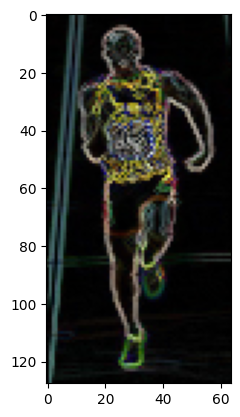

In [8]:
# Calculamos el gradiente con el kernel de Sobel
# El gradiente nos indica cómo cambia la intensidad de la imagen en cada punto
# Es fundamental para detectar bordes y para descriptores como HOG

# Convierte la imagen recortada a tipo float32 si no lo está ya
# Esto asegura precisión en los cálculos del gradiente (evita desbordamientos)
crop = np.float32(crop)

# Calcula el gradiente en la dirección X (horizontal) usando el kernel de Sobel
# cv2.Sobel(imagen, profundidad, dx, dy, tamaño_del_kernel)
# Parámetros:
#   - crop: imagen de entrada
#   - cv2.CV_32F: tipo de datos de salida (float32 para preservar gradientes negativos)
#   - 1, 0: derivada en x (dx=1, dy=0) → gradiente horizontal
#   - 0, 1: derivada en y (dx=0, dy=1) → gradiente vertical
#   - ksize=1: tamaño del kernel Sobel (1 = kernel 1x3, más pequeño y sensible)
# El kernel Sobel para ksize=1 es: [-1, 0, 1] para gradiente horizontal
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)

# Calcula el gradiente en la dirección Y (vertical)
# Detecta cambios en dirección vertical (bordes horizontales)
# Kernel Sobel vertical: [-1, 0, 1]^T
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)

# Calculamos la magnitud y la dirección del gradiente
# cv2.cartToPolar convierte coordenadas cartesianas (gx, gy) a polares (magnitud, ángulo)
# Parámetros:
#   - gx: gradiente en x (componente horizontal)
#   - gy: gradiente en y (componente vertical)
#   - angleInDegrees=True: devuelve el ángulo en grados (False = radianes)
# Retorna:
#   - mag: magnitud del gradiente (sqrt(gx² + gy²)) - intensidad del borde
#   - angle: dirección del gradiente (arctan(gy/gx)) - orientación del borde
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Visualizamos la imagen obtenida en la magnitud del gradiente

# Normaliza la magnitud al rango [0, 1] dividiendo por el valor máximo
# Esto es necesario para visualizar correctamente con matplotlib
# Sin normalización, los valores pueden estar fuera del rango [0,1] esperado
mag = mag / np.max(mag)

# Muestra la imagen de magnitud del gradiente
# Los píxeles más brillantes indican bordes más fuertes (mayor cambio de intensidad)
# Los píxeles oscuros indican regiones uniformes (poco cambio)
plt.imshow(mag, cmap='gray')

# Título opcional para entender la visualización
# plt.title('Magnitud del gradiente - Bordes detectados')

# Muestra la ventana con la imagen
plt.show()

# También podríamos visualizar la dirección del gradiente (ángulo)
# Descomenta para ver la imagen de orientaciones:
# plt.figure()
# plt.imshow(angle, cmap='hsv')  # 'hsv' es mejor para ángulos
# plt.colorbar(label='Ángulo (grados)')
# plt.title('Dirección del gradiente')
# plt.show()

In [9]:
# Cálculo del descriptor: Histogram of Oriented Gradients (HOG)
# HOG es un descriptor de características que cuenta ocurrencias de orientaciones de gradientes
# Es muy utilizado en visión por computadora para detección de objetos

# Importa la función hog de scikit-image
from skimage.feature import hog

# Línea comentada: imprime la imagen recortada (útil para depuración pero muy grande)
# print(crop)

# Imprime la dimensión (shape) de la imagen recortada
# crop.shape devuelve una tupla con (alto, ancho, canales) o (alto, ancho) si es gris
# Por ejemplo: (128, 64, 3) para una imagen RGB de 128x64 píxeles
print(crop.shape)

# Convierte la imagen de color BGR a escala de grises
# IMPORTANTE: crop está en formato BGR (porque se usó cv2.resize anteriormente)
# cv2.COLOR_BGR2GRAY: convierte de BGR (Blue-Green-Red) a escala de grises
# La imagen en grises es necesaria para HOG porque trabaja con un solo canal
img_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

# Calcula el descriptor HOG
# Parámetros:
#   - crop: imagen de entrada (NOTA: debería ser img_gray, no crop)
#   - orientations=9: número de bins del histograma (0°, 20°, 40°, ..., 160°)
#                    9 orientaciones cubren 0-180° (gradientes sin signo)
#   - pixels_per_cell=(8, 8): tamaño de cada celda en píxeles
#                             Cada celda de 8x8 píxeles genera un histograma
#   - cells_per_block=(2, 2): número de celdas por bloque para normalización
#                             Cada bloque de 2x2 celdas (16x16 píxeles)
#   - transform_sqrt=True: aplica raíz cuadrada a la imagen para normalización
#                          Reduce el efecto de variaciones de iluminación
#   - block_norm="L1": tipo de normalización de bloques
#                      L1 = normalización por suma absoluta (más robusta)
#                      Otras opciones: "L2", "L2-Hys"
#   - channel_axis=-1: indica el eje de los canales de color
#                      -1 significa el último eje (útil para imágenes RGB)
#                      Si la imagen es RGB, calcula HOG para cada canal
H = hog(crop, orientations=9, pixels_per_cell=(8, 8), 
        cells_per_block=(2, 2), transform_sqrt=True, 
        block_norm="L1", channel_axis=-1)

# Imprime la dimensión del descriptor HOG
# np.shape(H) devuelve la forma del arreglo (número de características)
# El tamaño esperado para una imagen de 128x64 es:
# (128/8) * (64/8) * (2*2) * 9 = 16 * 8 * 4 * 9 = 4608 características
np.shape(H)

# Para ver realmente la dimensión, deberías usar print:
print(f"Dimensión del descriptor HOG: {np.shape(H)}")
print(f"Número de características: {len(H)}")

(128, 64, 3)
Dimensión del descriptor HOG: (3780,)
Número de características: 3780


# 0.0.4 Local Binary Patterns

Dimensión imagen original: (539, 540)
Valores únicos en imagen LBP: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Frecuencias: [  9244  10408   2594  30871  14530  60955  25100  12184 110569  14605]
Número de patrones únicos: 10
El histograma tiene 10 bins (características)


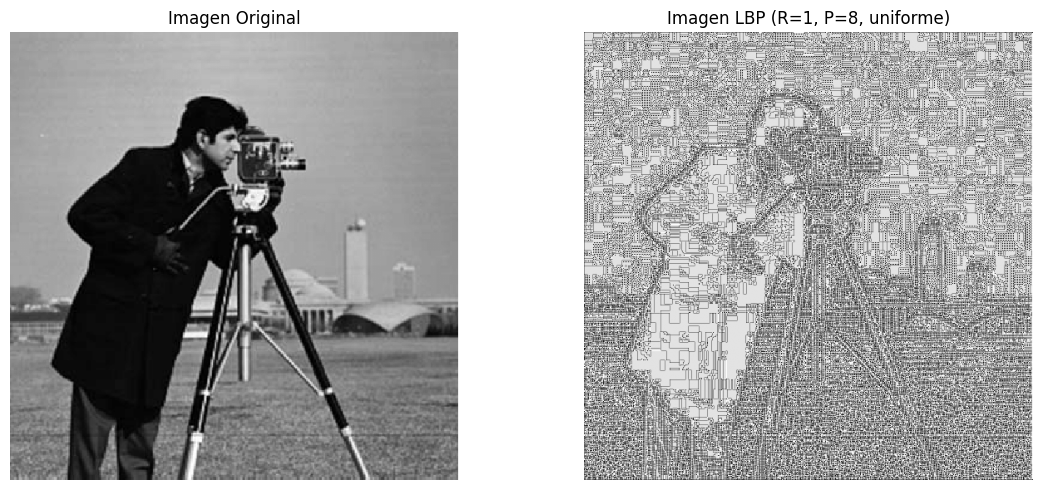

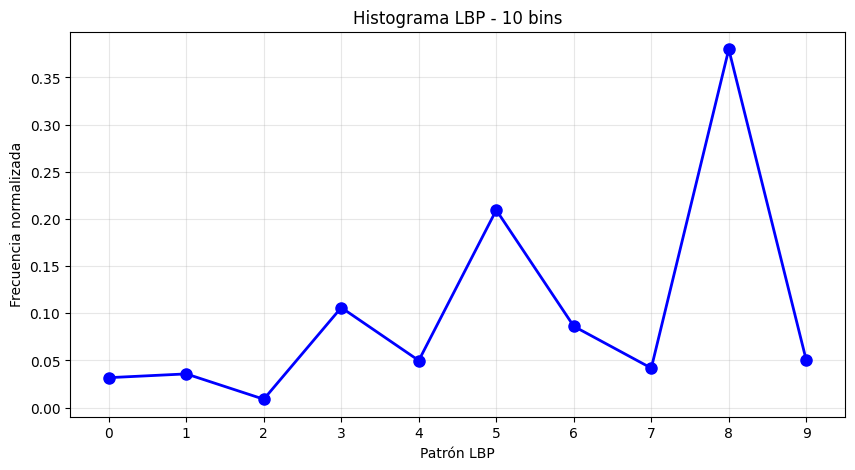


Valores del histograma (características):
Bin 0: 0.0318
Bin 1: 0.0358
Bin 2: 0.0089
Bin 3: 0.1061
Bin 4: 0.0499
Bin 5: 0.2094
Bin 6: 0.0862
Bin 7: 0.0419
Bin 8: 0.3799
Bin 9: 0.0502


In [10]:
# LOCAL BINARY PATTERNS (LBP)
# LBP es un descriptor de textura que compara cada píxel con sus vecinos
# Es muy utilizado en reconocimiento facial, clasificación de texturas y análisis de imágenes médicas

from skimage.feature import local_binary_pattern
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lee la imagen del fotógrafo desde la ruta especificada
# cv2.imread() carga en formato BGR (Blue-Green-Red)
img = cv2.imread('images/images/photographer.png')

# Verificar si la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen")
    exit()

# Definimos los parámetros iniciales para LBP
R = 1  # Radio: distancia desde el píxel central a los vecinos
       # R=1 significa vecinos inmediatos (3x3)
       # R=2 consideraría vecinos más lejanos (5x5)

P = 8 * R  # Número de píxeles vecinos
           # Para R=1: P=8 vecinos (píxeles alrededor)
           # Para R=2: P=16 vecinos, etc.
           # Más vecinos = mayor detalle pero más computacional

epsilon = 1e-7  # Constante pequeña para evitar división por cero
                # Se usa al normalizar el histograma

# Extraemos la imagen LBP
# Primero convertimos a escala de grises (LBP trabaja con un solo canal)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(f"Dimensión imagen original: {img_gray.shape}")

# Calculamos la imagen LBP
# Parámetros:
#   - img_gray: imagen de entrada en escala de grises
#   - P: número de puntos vecinos
#   - R: radio
#   - method='uniform': modo uniforme de LBP
#     'uniform' reduce el número de patrones de 2^P a solo P+2 patrones
#     Los patrones uniformes tienen máximo 2 transiciones 0-1 en el patrón binario
lbp_image = local_binary_pattern(img_gray, P, R, method='uniform')

# Obtenemos los valores únicos en la imagen LBP y sus frecuencias
# a: valores únicos (patrones LBP)
# b: conteo de cada valor (para verificar)
a, b = np.unique(lbp_image, return_counts=True)
print(f"Valores únicos en imagen LBP: {a}")
print(f"Frecuencias: {b}")
print(f"Número de patrones únicos: {len(a)}")

# Calculamos el histograma de la imagen LBP
# Convertimos la imagen LBP a uint8 (enteros sin signo) para calcHist
lbp_image = np.uint8(lbp_image)

# calcHist: calcula histograma de la imagen
# Parámetros:
#   - [lbp_image.ravel()]: imagen aplanada (vector 1D)
#   - [0]: canal a utilizar (solo 1 canal)
#   - None: máscara (None = toda la imagen)
#   - [P+2]: número de bins (para LBP uniforme: P+2 = 8+2 = 10 bins)
#   - [0, P+2]: rango de valores (0 a 10)
hist = cv2.calcHist([lbp_image.ravel()], [0], None, [P+2], [0, P+2])

# Normalizamos el histograma para que sume 1
# Esto hace que sea independiente del tamaño de la imagen
hist = hist.astype("float")  # Convertir a float para división
hist /= (hist.sum() + epsilon)  # Suma epsilon para evitar división por cero

# Los P+2 = 10 bins del histograma serán los 10 atributos que nos permitirán caracterizar una imagen
print(f"El histograma tiene {P+2} bins (características)")

# Visualizamos la imagen original y la imagen LBP
figs, ax = plt.subplots(1, 2, figsize=(12, 5))

# Mostrar imagen original (convertir BGR a RGB para colores correctos)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ax[0].imshow(img_rgb)
ax[0].set_title('Imagen Original')
ax[0].axis('off')

# Mostrar imagen LBP
ax[1].imshow(lbp_image, cmap='gray')
ax[1].set_title(f'Imagen LBP (R={R}, P={P}, uniforme)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Visualizamos el histograma de patrones LBP
plt.figure(figsize=(10, 5))
plt.plot(hist, 'b-o', linewidth=2, markersize=8)
plt.grid(True, alpha=0.3)
plt.title(f'Histograma LBP - {P+2} bins')
plt.xlabel('Patrón LBP')
plt.ylabel('Frecuencia normalizada')
plt.xticks(range(P+2), [f'{i}' for i in range(P+2)])
plt.xlim(-0.5, P+1.5)
plt.show()

# Mostrar los valores del histograma
print("\nValores del histograma (características):")
for i, valor in enumerate(hist.flatten()):
    print(f"Bin {i}: {valor:.4f}")